In [17]:
import os, requests, json
from dotenv import load_dotenv
from fredapi import Fred
import pandas as pd

In [18]:
load_dotenv("FRED_API_Key.env")
fred_key = os.environ["FRED_API_Key"]

fred = Fred(api_key=fred_key)
electricity_cpi = fred.get_series("CUUR0000SEHF01")

print(electricity_cpi.shape)
electricity_cpi.tail()

(1350,)


2026-01-01    299.731
2026-02-01    296.798
2026-03-01    299.028
2026-04-01    304.095
2026-05-01    307.226
dtype: float64

<Axes: title={'center': 'Electricity CPI (CUUR0000SEHF01)'}>

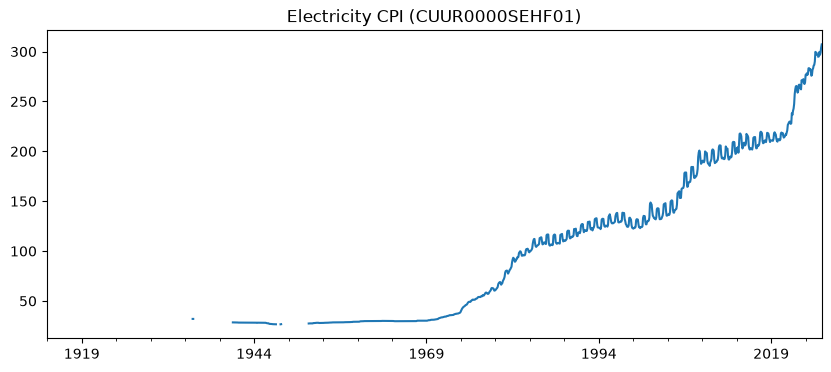

In [19]:
electricity_cpi.plot(title="Electricity CPI (CUUR0000SEHF01)", figsize=(10,4))

In [20]:
ids = {"electricity": "CUUR0000SEHF01", "all_items_cpi": "CPIAUCSL", "energy_cpi": "CPIENGSL"}
macro = pd.DataFrame({name: fred.get_series(sid) for name, sid in ids.items()})

In [ ]:
# Persist the macro series so build/analysis can use it
import os
macro.index.name = "date"
os.makedirs("../processed", exist_ok=True)
macro.to_csv("../processed/macro.csv")
print("saved ../processed/macro.csv  shape:", macro.shape)
macro.tail(3)